<a href="https://colab.research.google.com/github/pateld07/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is called linear when the prediction is made by adding variables multiplied by coefficients. It is linear in the coefficients, meaning the coefficients are not multiplied together or raised to powers. Even if variables are transformed the model is still linear as long as the coefficients stay linear.

2. A dummy variable represents a category, and one category is left out as the reference group. The coefficient shows how much the predicted value changes compared to that reference category. It tells us the difference between that category and the baseline while holding other variables constant.

3. Linear regression can technically be used for classification, but it is usually not a good choice. This is because it predicts continuous values, which can fall below 0 or above 1. Classification usually needs probabilities between 0 and 1, so models like logistic regression are better.

4. Overfitting happens when a model learns the training data too closely. A common sign is when the model performs very well on training data but poorly on test data. It can also happen when the model has too many variables or is too complex.

5. Multicollinearity occurs when two or more independent variables are highly related to each other. In the two-stage least squares idea, we first try to predict one variable using the others. If it can be predicted very well, it means the variable does not add much new information. This makes the regression coefficients harder to interpret.

6. Nonlinear relationships can be added by transforming the variables. For example, we can include squared terms, cubic terms, logs, etc. These allow the model to capture curved relationships instead of just straight lines.

7. The slope coefficient tells us how much the predicted value of
𝑦 changes when one independent variable increases by one unit. This interpretation assumes that all other variables in the model stay constant. It shows the relationship between that variable and the outcome.

8. A train/test split divides the dataset into two parts: one for training and one for testing. K-fold cross validation splits the data into several parts and trains the model multiple times, using a different part for testing each time. This usually gives a more reliable estimate of model performance.

9. The value of 𝑘 is usually chosen to balance accuracy and computation time. In practice, people often use 5 or 10 folds. These values tend to give reliable results without taking too long to run.

In [1]:
! git clone https://github.com/pateld07/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 27 (delta 5), reused 4 (delta 4), pack-reused 17 (from 1)
Receiving objects: 100% (27/27), 30.33 KiB | 15.17 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Download complete
Extracting data files...
Data extracted


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

The most expensive borough on average is Manhattan.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

I created dummy variables for neighbourhood and dropped one category (Bronx) to avoid multicollinearity. The intercept represents the average price in the Bronx, and each coefficient shows how much more expensive another borough is compared to the Bronx. These coefficients match the differences in average prices from the group means.


3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

The slope coefficient is about 1.02, meaning a one-point increase in review score increases price by about $1 on average. This effect is statistically significant but very small. The low R² shows that rating alone does not explain much of the variation in price.


4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

The slope coefficient is about 1.02, meaning a one-point increase in review score increases price by about $1 on average. This effect is statistically significant but very small. The low R² shows that rating alone does not explain much of the variation in price.


5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

The interaction model allows the effect of rating to differ across neighbourhoods. Most neighbourhoods have similar slopes, but Staten Island shows a very different and significant effect. This suggests the impact of ratings on price is not the same everywhere.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

The model with both neighbourhood and rating has the highest cross-validated R² (about 0.051). The neighbourhood-only model performs almost as well, while rating alone performs very poorly. This shows that neighbourhood is much more important than rating for predicting price.


Used Chat GPT for Slope coefficient

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("./sample_data/Q1_clean.csv", encoding="latin1")

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["review_scores_rating"] = pd.to_numeric(df["review_scores_rating"], errors="coerce")

tdf = df[["price", "review_scores_rating", "neighbourhood"]].dropna()

In [23]:
grouped = tdf.groupby("neighbourhood")[["price", "review_scores_rating"]].mean()
print(grouped)

print("Most expensive borough:", grouped["price"].idxmax())

                    price  review_scores_rating
neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive borough: Manhattan


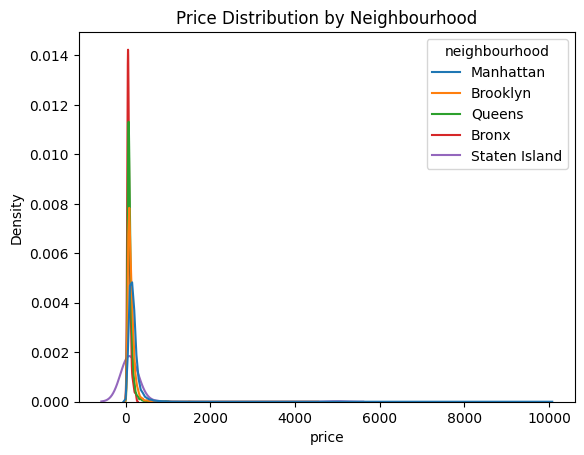

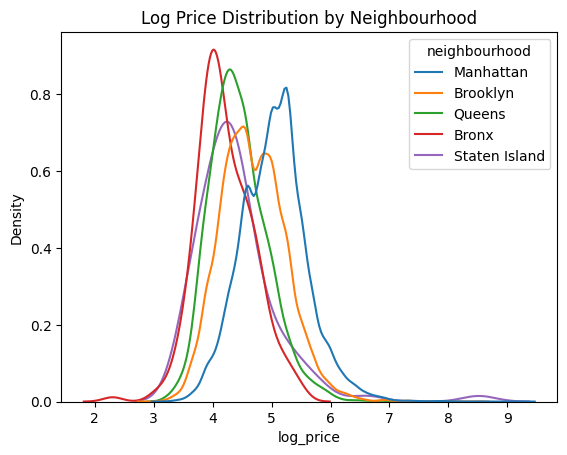

In [24]:
sns.kdeplot(data=tdf, x="price", hue="neighbourhood", common_norm=False)
plt.title("Price Distribution by Neighbourhood")
plt.show()

tdf["log_price"] = np.log(tdf["price"])

sns.kdeplot(data=tdf, x="log_price", hue="neighbourhood", common_norm=False)
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

In [25]:
dummies = pd.get_dummies(tdf["neighbourhood"], drop_first=True, dtype=int)

X1 = sm.add_constant(dummies)
y = tdf["price"]

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        23:58:02   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [26]:
X2 = sm.add_constant(tdf["review_scores_rating"])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        23:59:33   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

In [27]:
X3 = pd.concat([dummies, tdf[["review_scores_rating"]]], axis=1)
X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        23:59:42   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

In [28]:
X4 = dummies.copy()
X4["review_scores_rating"] = tdf["review_scores_rating"]

for col in dummies.columns:
    X4[f"{col}_x_rating"] = dummies[col] * tdf["review_scores_rating"]

X4 = sm.add_constant(X4)

model4 = sm.OLS(y, X4).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:59:54   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     22

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

X_cv1 = dummies
X_cv2 = tdf[["review_scores_rating"]]
X_cv3 = pd.concat([dummies, tdf[["review_scores_rating"]]], axis=1)

for name, X in [("Neighborhood only", X_cv1),
                ("Rating only", X_cv2),
                ("Neighborhood + Rating", X_cv3)]:
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(name)
    print("Mean CV R^2:", np.mean(scores))
    print()

Neighborhood only
Mean CV R^2: 0.046361800897961734

Rating only
Mean CV R^2: 0.0014611836791742494

Neighborhood + Rating
Mean CV R^2: 0.050757126437275014



**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

  The Price distribution is right-skewed, UVs are the most expensive on average, while they also show the most spread in the KDE plot, indicating the highest variance. Hatchbacks and crossovers are cheaper and more tightly clustered, meaning they have less variation in price.

  
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

  The slope coefficient is about 59,270, meaning each additional seat increases price by about ₹59k on average. When Seating_Capacity is treated as categorical, the coefficients do not increase evenly . This shows the relationship is not perfectly linear in the number of seats.


  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

The scatter plot shows that price generally decreases as age increases. The model prediction line follows this downward trend but smooths over a lot of the variation in the data. Overall, the model captures the main pattern but does not perfectly fit all the points.

Used Chat GPT for Coefficient

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

df = pd.read_csv("./sample_data/cars_hw.csv", encoding="latin1")

df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


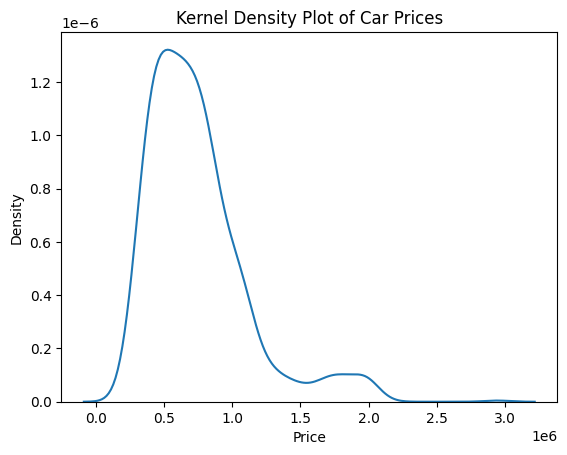

In [8]:
sns.kdeplot(data=df, x="Price")
plt.title("Kernel Density Plot of Car Prices")
plt.show()

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


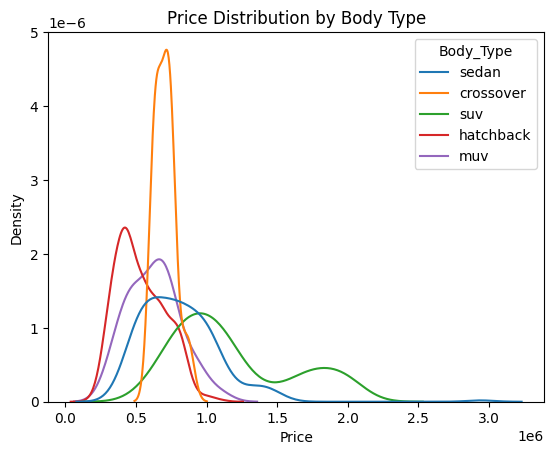

In [9]:
body_summary = df.groupby("Body_Type")["Price"].describe()
print(body_summary)

sns.kdeplot(data=df, x="Price", hue="Body_Type", common_norm=False)
plt.title("Price Distribution by Body Type")
plt.show()

In [10]:
X1 = sm.add_constant(df["Seating_Capacity"])
y = df["Price"]

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Fri, 20 Mar 2026   Prob (F-statistic):             0.0245
Time:                        18:56:18   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [11]:
seat_dummies = pd.get_dummies(df["Seating_Capacity"], drop_first=True, dtype=int)

X2 = sm.add_constant(seat_dummies)
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           0.000267
Time:                        18:56:32   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

In [12]:
df["Age"] = 2026 - df["Make_Year"]
print(df[["Make_Year", "Age"]].head())

   Make_Year  Age
0       2017    9
1       2016   10
2       2019    7
3       2017    9
4       2017    9


In [13]:
cv_results = {}

for p in range(1, 6):
    X_poly = pd.DataFrame()
    for i in range(1, p + 1):
        X_poly[f"Age^{i}"] = df["Age"] ** i

    model = LinearRegression()
    scores = cross_val_score(model, X_poly, df["Price"], cv=10, scoring="r2")
    cv_results[p] = scores.mean()

print(cv_results)

{1: np.float64(0.2054391565742792), 2: np.float64(0.2045700162564402), 3: np.float64(0.20679554482905066), 4: np.float64(0.20072321783336283), 5: np.float64(0.19704777544091334)}


In [15]:
best_p = 3

X_best = pd.DataFrame()
for i in range(1, best_p + 1):
    X_best[f"Age^{i}"] = df["Age"] ** i

best_model = LinearRegression()
best_model.fit(X_best, df["Price"])

df["Predicted_Price"] = best_model.predict(X_best)

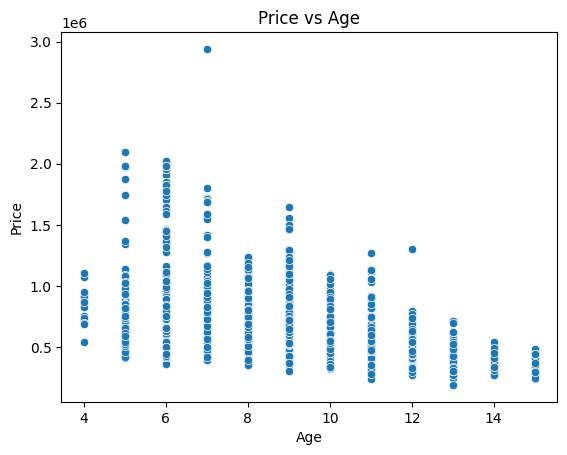

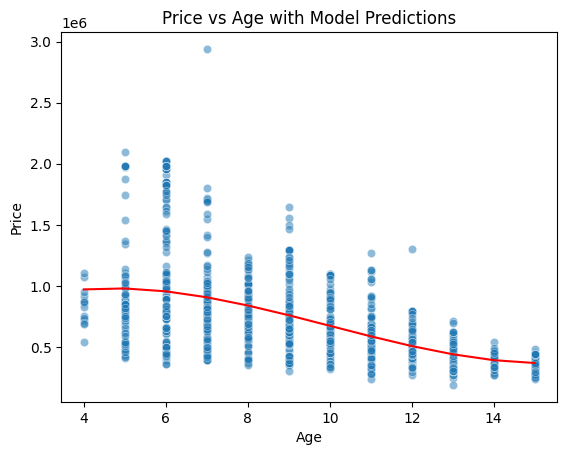

In [16]:

sns.scatterplot(data=df, x="Age", y="Price")
plt.title("Price vs Age")
plt.show()


df_sorted = df.sort_values("Age")

sns.scatterplot(data=df, x="Age", y="Price", alpha=0.5)
plt.plot(df_sorted["Age"], df_sorted["Predicted_Price"], color="red")
plt.title("Price vs Age with Model Predictions")
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

The survival rate is 0.118 for the control group and 0.348 for the treatment group. The ATE is 0.348 − 0.118 = 0.230, meaning transplants increase three-year survival by about 23 percentage points on average. This is the raw difference in survival between the two groups.

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

The intercept (0.118) equals the control group survival rate, and the transplant coefficient (0.230) equals the ATE from part 1. This shows that the linear model with a binary variable exactly reproduces the group means. So the regression confirms the difference in survival between treatment and control.


3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

When controlling for age, the transplant effect increases from 0.230 to 0.265. The intercept represents predicted survival for a control patient at age 0, and the age coefficient means survival decreases with age. Since the treatment effect is constant across ages, the ATE of 0.230 underestimates the transplant effect at all ages.

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

With the interaction, the transplant effect becomes 0.908 − 0.0146 × age, meaning it decreases as age increases. This shows transplants are much more beneficial for younger patients and less effective for older ones. The ATE underestimates the effect for younger patients and overestimates it for older patients, with the crossover around age 46.5.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

This is observational data, so differences between treatment and control groups may be due to selection bias rather than true causal effects. The models also have poor predictive performance, so using them for real decisions could be unreliable. Additionally, the interaction model suggests older patients benefit less, which raises ethical concerns if used to prioritize transplants.

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [24]:
df = pd.read_csv("./sample_data/heart_hw.csv", encoding="latin1")
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [25]:
group_means = df.groupby("transplant")["y"].mean()
print(group_means)

control_survival = group_means["control"]
treatment_survival = group_means["treatment"]
ATE = treatment_survival - control_survival

print("Control survival rate:", control_survival)
print("Treatment survival rate:", treatment_survival)
print("ATE:", ATE)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


In [26]:
df["transplant_dummy"] = (df["transplant"] == "treatment").astype(int)

X1 = sm.add_constant(df["transplant_dummy"])
y = df["y"]

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Fri, 20 Mar 2026   Prob (F-statistic):             0.0133
Time:                        19:25:35   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1176      0.075  

In [27]:
X2 = sm.add_constant(df[["transplant_dummy", "age"]])

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           0.000357
Time:                        19:25:48   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7020      0.196  

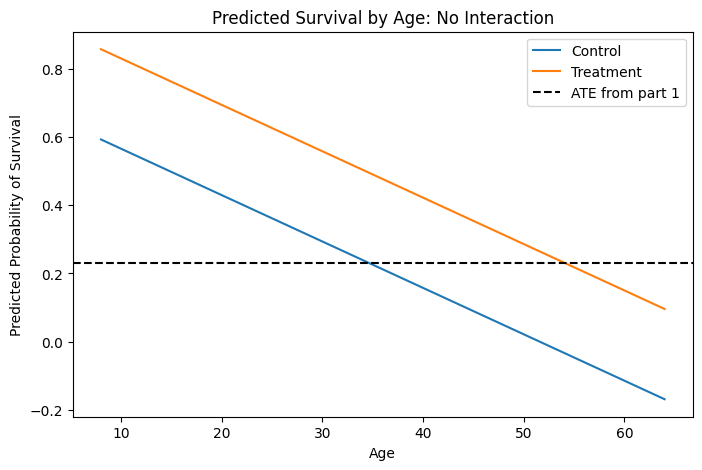

In [29]:
age_grid = pd.DataFrame({"age": np.linspace(df["age"].min(), df["age"].max(), 200)})

pred_control = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 0,
    "age": age_grid["age"]
})

pred_treat = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 1,
    "age": age_grid["age"]
})

age_grid["pred_control"] = model2.predict(pred_control)
age_grid["pred_treat"] = model2.predict(pred_treat)
age_grid["treatment_effect"] = age_grid["pred_treat"] - age_grid["pred_control"]

plt.figure(figsize=(8,5))
plt.plot(age_grid["age"], age_grid["pred_control"], label="Control")
plt.plot(age_grid["age"], age_grid["pred_treat"], label="Treatment")
plt.axhline(ATE, color="black", linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.title("Predicted Survival by Age: No Interaction")
plt.legend()
plt.show()

In [30]:
age_grid[["age", "treatment_effect"]].head()

,age,treatment_effect
0,8.000000,0.264702
1,8.281407,0.264702
2,8.562814,0.264702
3,8.844221,0.264702
4,9.125628,0.264702


In [31]:
df["transplant_age"] = df["transplant_dummy"] * df["age"]

X3 = sm.add_constant(df[["transplant_dummy", "age", "transplant_age"]])

model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           0.000310
Time:                        19:26:55   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3549      0.280  

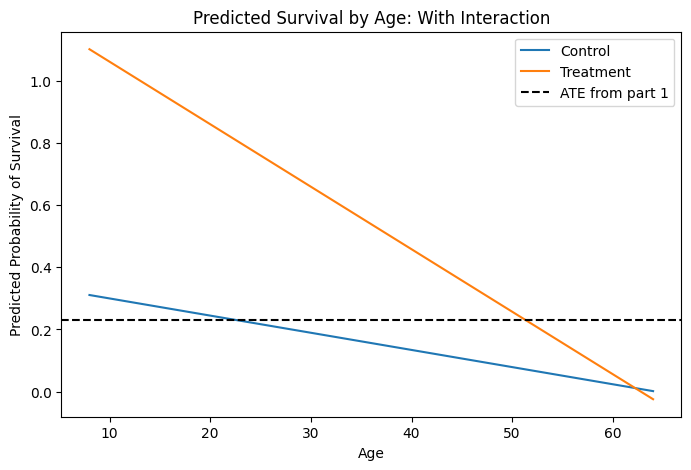

In [32]:
pred_control_int = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 0,
    "age": age_grid["age"],
    "transplant_age": 0
})

pred_treat_int = pd.DataFrame({
    "const": 1,
    "transplant_dummy": 1,
    "age": age_grid["age"],
    "transplant_age": age_grid["age"]
})

age_grid["pred_control_int"] = model3.predict(pred_control_int)
age_grid["pred_treat_int"] = model3.predict(pred_treat_int)
age_grid["treatment_effect_int"] = age_grid["pred_treat_int"] - age_grid["pred_control_int"]

plt.figure(figsize=(8,5))
plt.plot(age_grid["age"], age_grid["pred_control_int"], label="Control")
plt.plot(age_grid["age"], age_grid["pred_treat_int"], label="Treatment")
plt.axhline(ATE, color="black", linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.title("Predicted Survival by Age: With Interaction")
plt.legend()
plt.show()

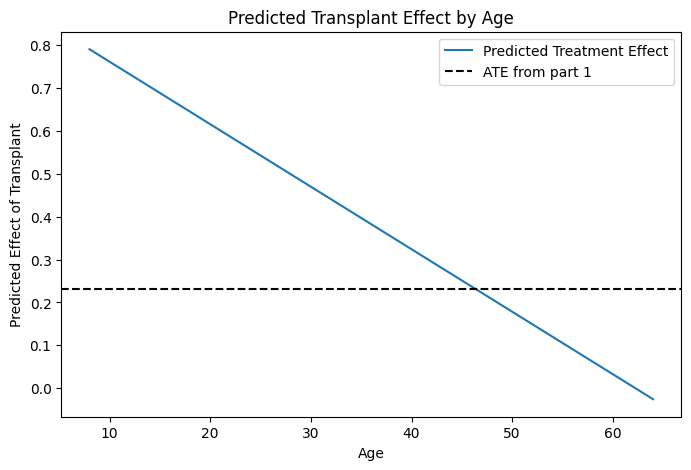

In [33]:
plt.figure(figsize=(8,5))
plt.plot(age_grid["age"], age_grid["treatment_effect_int"], label="Predicted Treatment Effect")
plt.axhline(ATE, color="black", linestyle="--", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted Effect of Transplant")
plt.title("Predicted Transplant Effect by Age")
plt.legend()
plt.show()

In [34]:
age_grid["diff_from_ATE"] = age_grid["treatment_effect_int"] - ATE

closest_age = age_grid.iloc[(age_grid["diff_from_ATE"].abs()).argmin()]
print("Age where model effect is closest to ATE:")
print(closest_age[["age", "treatment_effect_int"]])

Age where model effect is closest to ATE:
age                     46.552764
treatment_effect_int     0.228517
Name: 137, dtype: float64


In [35]:
X_cv1 = df[["transplant_dummy"]]
X_cv2 = df[["transplant_dummy", "age"]]
X_cv3 = df[["transplant_dummy", "age", "transplant_age"]]
y = df["y"]

for name, X in [
    ("Transplant only", X_cv1),
    ("Transplant + age", X_cv2),
    ("Transplant + age + interaction", X_cv3)
]:
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=10, scoring="r2")
    print(name)
    print("CV R^2 scores:", scores)
    print("Mean CV R^2:", np.mean(scores))
    print()

Transplant only
CV R^2 scores: [ 0.         -0.39967725 -0.01281499  0.          0.          0.08866264
 -0.57164479 -1.86392476 -0.36239586 -0.92211728]
Mean CV R^2: -0.4043912290011423

Transplant + age
CV R^2 scores: [ 0.         -0.80481243 -0.07206204  0.          0.          0.44092856
 -1.76872954 -2.0376119  -0.082461   -0.62357875]
Mean CV R^2: -0.4948327098378075

Transplant + age + interaction
CV R^2 scores: [ 0.         -0.84878581  0.08453514  0.          0.          0.56816435
 -1.62764372 -2.48778396  0.02074505 -0.6191084 ]
Mean CV R^2: -0.49098773603660933

